In [ ]:
%pip install tensorflow


   ---------------------------------------- 0.0/351.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/351.2 MB ? eta -:--:--
   ---------------------------------------- 0.3/351.2 MB ? eta -:--:--
   ---------------------------------------- 1.3/351.2 MB 4.2 MB/s eta 0:01:24
   ---------------------------------------- 2.4/351.2 MB 4.0 MB/s eta 0:01:27
   ---------------------------------------- 3.1/351.2 MB 4.0 MB/s eta 0:01:27
   ---------------------------------------- 3.9/351.2 MB 4.0 MB/s eta 0:01:27
    --------------------------------------- 4.7/351.2 MB 4.0 MB/s eta 0:01:27
    --------------------------------------- 5.5/351.2 MB 4.0 MB/s eta 0:01:27
    --------------------------------------- 6.3/351.2 MB 4.0 MB/s eta 0:01:27
    --------------------------------------- 7.3/351.2 MB 4.0 MB/s eta 0:01:27
    --------------------------------------- 7.6/351.2 MB 4.0 MB/s eta 0:01:27
    --------------------------------------- 7.9/351.2 MB 3.6 MB/s eta 0:01:35
   - -

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
streamlit 1.45.1 requires protobuf<7,>=3.20, but you have protobuf 7.35.1 which is incompatible.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

from keras.models import Sequential
from keras.layers import Dense, Input



In [11]:
Data = pd.read_csv('bengaluru_house_prices.csv')

In [12]:
Data.head(20)

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00
5,Super built-up Area,Ready To Move,Whitefield,2 BHK,DuenaTa,1170,2.0,1.0,38.00
6,Super built-up Area,18-May,Old Airport Road,4 BHK,Jaades,2732,4.0,NaN,204.00
7,Super built-up Area,Ready To Move,Rajaji Nagar,4 BHK,Brway G,3300,4.0,NaN,600.00
8,Super built-up Area,Ready To Move,Marathahalli,3 BHK,NaN,1310,3.0,1.0,63.25
9,Plot Area,Ready To Move,Gandhi Bazar,6 Bedroom,NaN,1020,6.0,NaN,370.00


In [5]:
Data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     13320 non-null  object 
 1   availability  13320 non-null  object 
 2   location      13319 non-null  object 
 3   size          13304 non-null  object 
 4   society       7818 non-null   object 
 5   total_sqft    13320 non-null  object 
 6   bath          13247 non-null  float64
 7   balcony       12711 non-null  float64
 8   price         13320 non-null  float64
dtypes: float64(3), object(6)
memory usage: 936.7+ KB


In [ ]:
#For numerical columns
summary = Data.describe()
print(summary)

               bath       balcony         price
count  13247.000000  12711.000000  13320.000000
mean       2.692610      1.584376    112.565627
std        1.341458      0.817263    148.971674
min        1.000000      0.000000      8.000000
25%        2.000000      1.000000     50.000000
50%        2.000000      2.000000     72.000000
75%        3.000000      2.000000    120.000000
max       40.000000      3.000000   3600.000000


In [ ]:
#For All columns
Data.describe(include='all')

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
count,13320,13320,13319,13304,7818,13320,13247.000000,12711.000000,13320.000000
unique,4,81,1305,31,2688,2117,NaN,NaN,NaN
top,Super built-up Area,Ready To Move,Whitefield,2 BHK,GrrvaGr,1200,NaN,NaN,NaN
freq,8790,10581,540,5199,80,843,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,2.692610,1.584376,112.565627
std,NaN,NaN,NaN,NaN,NaN,NaN,1.341458,0.817263,148.971674
min,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,0.000000,8.000000
25%,NaN,NaN,NaN,NaN,NaN,NaN,2.000000,1.000000,50.000000
50%,NaN,NaN,NaN,NaN,NaN,NaN,2.000000,2.000000,72.000000
75%,NaN,NaN,NaN,NaN,NaN,NaN,3.000000,2.000000,120.000000


In [15]:
missing = Data.isnull().sum().sort_values(ascending=False)

missing_percent = (Data.isnull().sum() / len(Data) * 100).sort_values(ascending=False)

missing_table = pd.DataFrame({
    'Missing Values': missing,
    'Percentage': missing_percent
})

print(missing_table)

              Missing Values  Percentage
society                 5502   41.306306
balcony                  609    4.572072
bath                      73    0.548048
size                      16    0.120120
location                   1    0.007508
area_type                  0    0.000000
availability               0    0.000000
total_sqft                 0    0.000000
price                      0    0.000000


In [ ]:
# Convert size column to numerical values
Data['size_num'] = Data['size'].str.extract('(\d+)').astype(float)

In [ ]:
Data.drop('size', axis=1, inplace=True)

In [ ]:
# Convert sqft column to numerical values
def convert_sqft(x):
    try:
        if isinstance(x, str):
            if '-' in x:
                values = x.split('-')
                return (float(values[0]) + float(values[1])) / 2
            
            return float(x)
        
        return float(x)
    
    except:
        return np.nan

In [19]:
Data['total_sqft'] = Data['total_sqft'].apply(convert_sqft)

In [24]:
Data.head(10)


,area_type,availability,location,society,total_sqft,bath,balcony,price,size_num
0,Super built-up Area,19-Dec,Electronic City Phase II,Coomee,1056.0,2.0,1.0,39.07,2.0
1,Plot Area,Ready To Move,Chikka Tirupathi,Theanmp,2600.0,5.0,3.0,120.00,4.0
2,Built-up Area,Ready To Move,Uttarahalli,NaN,1440.0,2.0,3.0,62.00,3.0
3,Super built-up Area,Ready To Move,Lingadheeranahalli,Soiewre,1521.0,3.0,1.0,95.00,3.0
4,Super built-up Area,Ready To Move,Kothanur,NaN,1200.0,2.0,1.0,51.00,2.0
5,Super built-up Area,Ready To Move,Whitefield,DuenaTa,1170.0,2.0,1.0,38.00,2.0
6,Super built-up Area,18-May,Old Airport Road,Jaades,2732.0,4.0,NaN,204.00,4.0
7,Super built-up Area,Ready To Move,Rajaji Nagar,Brway G,3300.0,4.0,NaN,600.00,4.0
8,Super built-up Area,Ready To Move,Marathahalli,NaN,1310.0,3.0,1.0,63.25,3.0
9,Plot Area,Ready To Move,Gandhi Bazar,NaN,1020.0,6.0,NaN,370.00,6.0


In [28]:
Data.isnull().sum()

area_type          0
availability       0
location           1
society         5502
total_sqft        46
bath              73
balcony          609
price              0
size_num          16
dtype: int64

In [33]:
Data['total_sqft'] = Data['total_sqft'].fillna(Data['total_sqft'].median())
Data['bath'] = Data['bath'].fillna(Data['bath'].median())
Data['balcony'] = Data['balcony'].fillna(Data['balcony'].median())
Data['size_num'] = Data['size_num'].fillna(Data['size_num'].median())

In [30]:
categorical_columns = ['area_type', 'availability', 'location', 'society']

for col in categorical_columns:
    Data[col] = Data[col].fillna('Unknown')

In [34]:
Data.isnull().sum()

area_type       0
availability    0
location        0
society         0
total_sqft      0
bath            0
balcony         0
price           0
size_num        0
dtype: int64

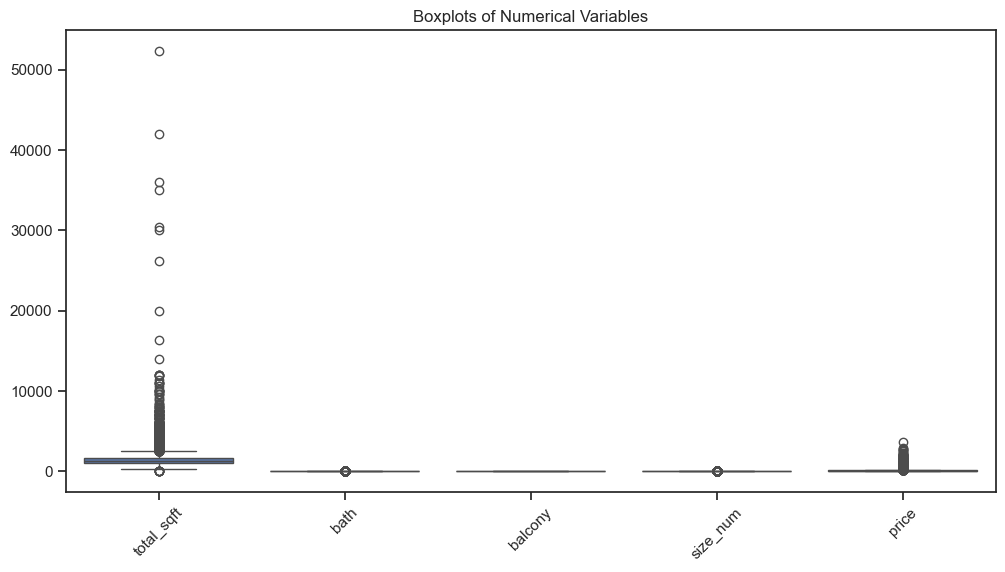

In [36]:
numerical_columns = [
    'total_sqft',
    'bath',
    'balcony',
    'size_num',
    'price'
]

plt.figure(figsize=(12, 6))
sns.boxplot(data=Data[numerical_columns])
plt.xticks(rotation=45)
plt.title('Boxplots of Numerical Variables')
plt.show()

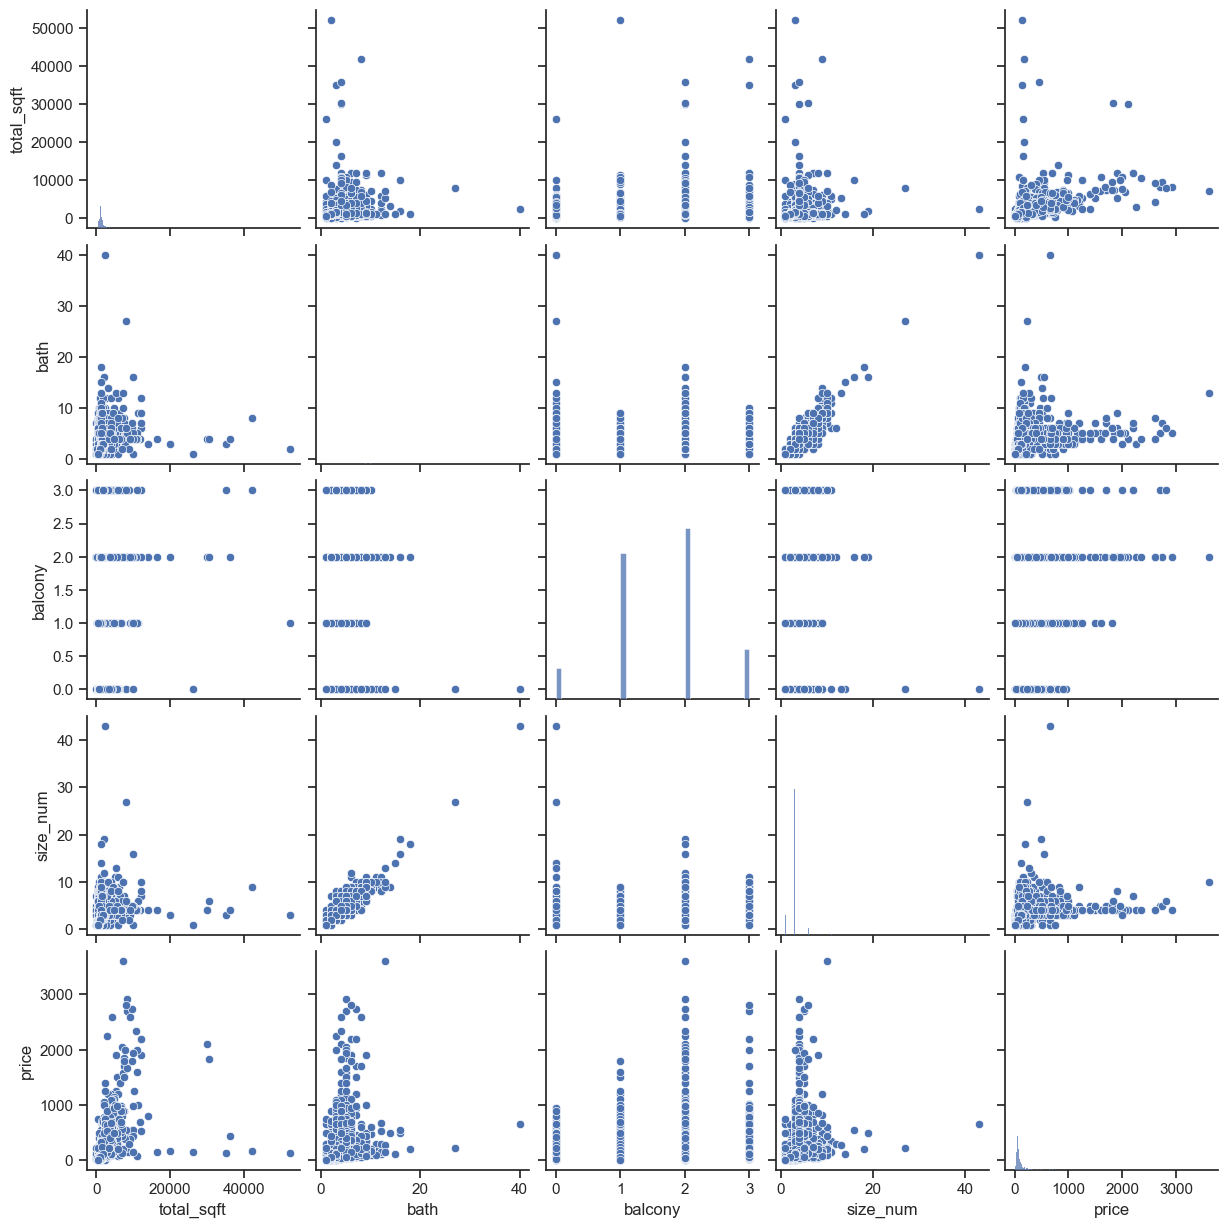

In [38]:
sns.pairplot(Data[numerical_columns])
plt.show()

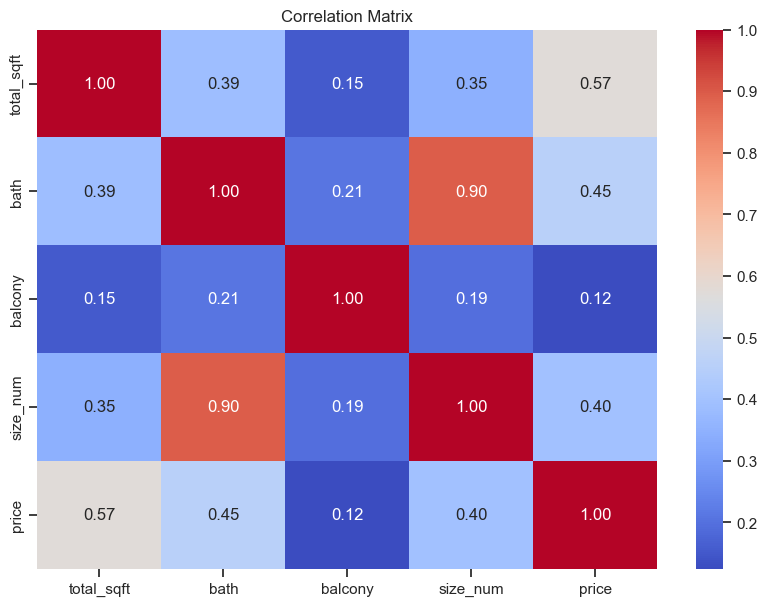

In [40]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    Data[numerical_columns].corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Matrix')
plt.show()

In [ ]:
# Encode categorical variables
DataEncoded = pd.get_dummies(
    Data,
    columns=['area_type', 'availability', 'location', 'society'],
    drop_first=True,
    dtype=int
)

In [42]:
DataEncoded.head()

,total_sqft,bath,balcony,price,size_num,area_type_Carpet Area,area_type_Plot Area,area_type_Super built-up Area,availability_14-Nov,availability_15-Aug,...,society_Xeitaa,society_YCnce R,society_YMhenLi,society_Yaenti,society_ZeodsWo,society_Zonce E,society_Zostaa,society_i1ncyRe,society_i1odsne,society_i1rtsCo
0,1056.0,2.0,1.0,39.07,2.0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
1,2600.0,5.0,3.0,120.00,4.0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1440.0,2.0,3.0,62.00,3.0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1521.0,3.0,1.0,95.00,3.0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
4,1200.0,2.0,1.0,51.00,2.0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0


In [43]:
DataEncoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Columns: 4081 entries, total_sqft to society_i1rtsCo
dtypes: float64(5), int64(4076)
memory usage: 414.7 MB


In [44]:
Predictors = DataEncoded.drop('price', axis=1)
Response = DataEncoded['price']

In [45]:
print(Predictors.shape)
print(Response.shape)

(13320, 4080)
(13320,)


In [ ]:
Pred_train, Pred_test, Resp_train, Resp_test =train_test_split(Predictors, Response,test_size = 0.2, random_state=1 ) 

print(Pred_train.shape)
print(Pred_test.shape)
print(Resp_train.shape)
print(Resp_test.shape)


(10656, 4080)
(2664, 4080)
(10656,)
(2664,)


In [48]:
scaler = MinMaxScaler()

Pred_train_scaled = scaler.fit_transform(Pred_train)
Pred_test_scaled = scaler.transform(Pred_test)

In [49]:
Pred_train_scaled = pd.DataFrame(
    Pred_train_scaled,
    columns=Predictors.columns,
    index=Pred_train.index
)

Pred_test_scaled = pd.DataFrame(
    Pred_test_scaled,
    columns=Predictors.columns,
    index=Pred_test.index
)

In [52]:
input_dim = Pred_train_scaled.shape[1]

In [ ]:
#Building The Fully Connected Neural Network model
model = Sequential()

model.add(Input(shape=(input_dim,)))

model.add(Dense(20, activation='relu'))

model.add(Dense(10, activation='relu'))

model.add(Dense(10, activation='relu'))

model.add(Dense(1, activation='linear'))

In [55]:
model.compile(optimizer='adam', loss='mean_squared_error', metrics=['mae'])

In [56]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 20)             │        81,620 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           210 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 81,951 (320.12 KB)

 Trainable params: 81,951 (320.12 KB)

 Non-trainable params: 0 (0.00 B)

In [58]:
history = model.fit(
    Pred_train_scaled,
    Resp_train,
    epochs=100,
    verbose=1,
    validation_split=0.2,
    batch_size=128
)

Epoch 1/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 35023.5195 - mae: 112.4723 - val_loss: 26138.0762 - val_mae: 105.4788
Epoch 2/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 33595.4844 - mae: 105.9732 - val_loss: 23517.2500 - val_mae: 92.4927
Epoch 3/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 28940.2656 - mae: 82.7377 - val_loss: 17710.9668 - val_mae: 61.5653
Epoch 4/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 23193.1133 - mae: 64.8657 - val_loss: 14434.9160 - val_mae: 61.7340
Epoch 5/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 21198.8418 - mae: 69.4760 - val_loss: 13824.1191 - val_mae: 64.2009
Epoch 6/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 20470.7148 - mae: 67.9876 - val_loss: 13351.6367 - val_mae: 63.4269
Epoch 7/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 19853.9082 - mae: 67.2322 - val_loss: 12886.8193 - val_mae: 60.9760
Epoch 8/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 19269.9141 - mae: 64.3973 - val_loss: 12472.5156 

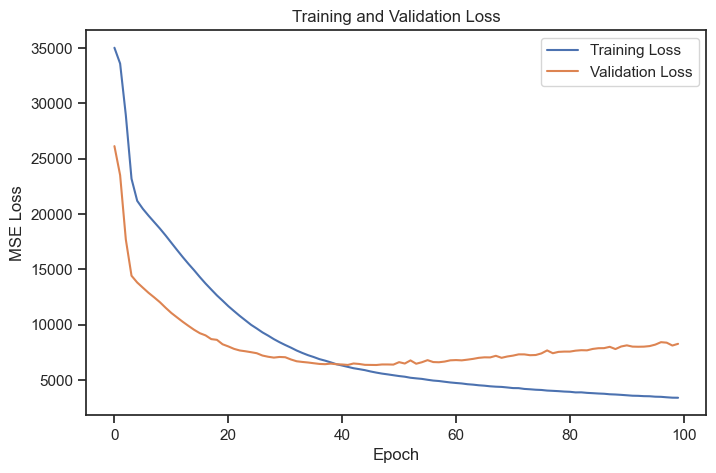

In [59]:
plt.figure(figsize=(8, 5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Training and Validation Loss')

plt.legend()
plt.show()

In [60]:
Y_pred = model.predict(Pred_test_scaled)

84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  


In [61]:
r2 = r2_score(Resp_test, Y_pred)

print("Coefficient of determination (R²):")
print(r2)

Coefficient of determination (R²):
0.47822428519342564


In [62]:
mse = mean_squared_error(Resp_test, Y_pred)

rmse = np.sqrt(mse)

mae = mean_absolute_error(Resp_test, Y_pred)

print("MSE :", mse)
print("RMSE:", rmse)
print("MAE :", mae)
print("R²  :", r2)

MSE : 14253.156108105619
RMSE: 119.38658261339764
MAE : 41.07674308252764
R²  : 0.47822428519342564


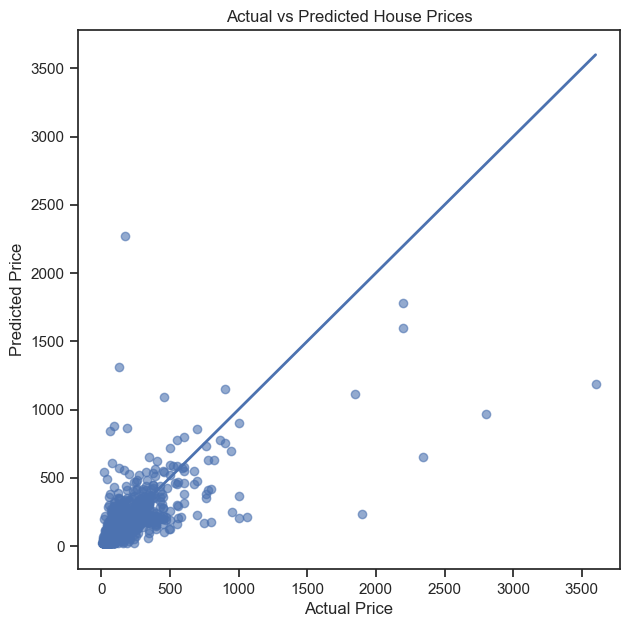

In [63]:
plt.figure(figsize=(7, 7))

plt.scatter(Resp_test, Y_pred, alpha=0.6)

minimum = min(Resp_test.min(), Y_pred.min())
maximum = max(Resp_test.max(), Y_pred.max())

plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    linewidth=2
)

plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted House Prices')

plt.show()

The model performs badly in the presence of outliers

In [65]:
outlier_columns = [
    'total_sqft',
    'bath',
    'balcony',
    'size_num',
    'price'
]

In [66]:
Q1 = Data[outlier_columns].quantile(0.25)
Q3 = Data[outlier_columns].quantile(0.75)

IQR = Q3 - Q1

print(IQR)

total_sqft    578.0
bath            1.0
balcony         1.0
size_num        1.0
price          70.0
dtype: float64


In [67]:
DataOut = Data[
    ~(
        (Data[outlier_columns] < (Q1 - 1.5 * IQR)) |
        (Data[outlier_columns] > (Q3 + 1.5 * IQR))
    ).any(axis=1)
]

In [68]:
print("Original shape:", Data.shape)
print("Without outliers:", DataOut.shape)

Original shape: (13320, 9)
Without outliers: (11110, 9)


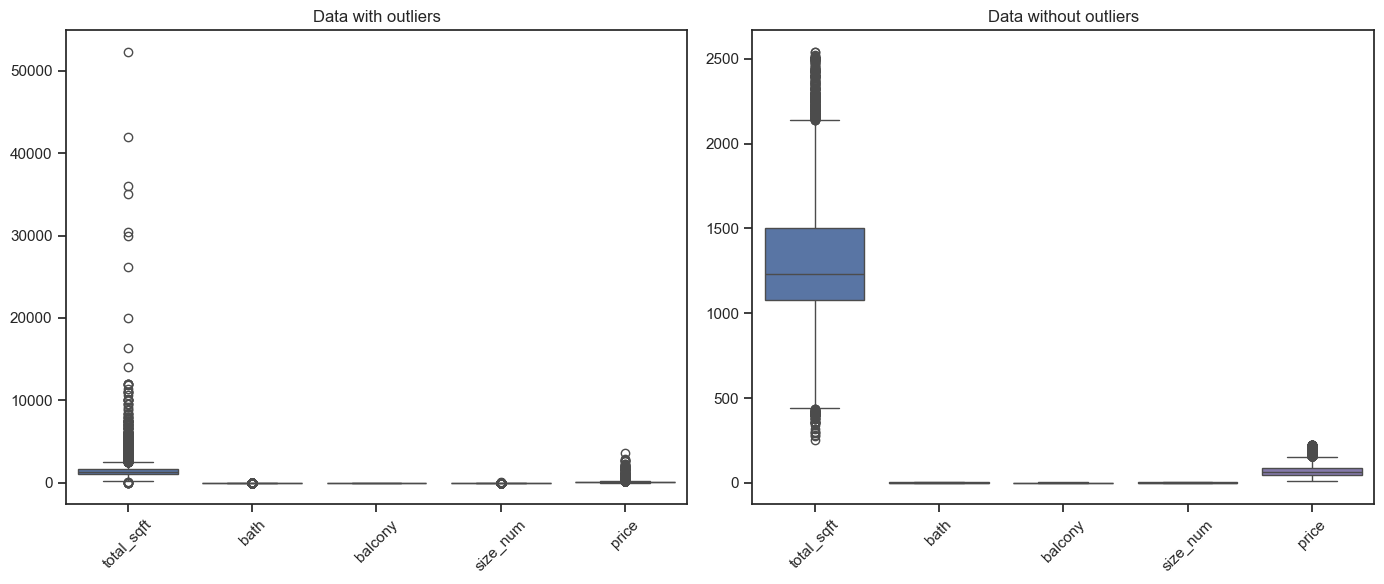

In [69]:
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)

sns.boxplot(data=Data[outlier_columns])

plt.title("Data with outliers")
plt.xticks(rotation=45)


plt.subplot(1, 2, 2)

sns.boxplot(data=DataOut[outlier_columns])

plt.title("Data without outliers")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [71]:
DataOut = DataOut.copy()

Predictors2 = DataOut.drop('price', axis=1)
Response2 = DataOut['price']

Predictors2 = pd.get_dummies(
    Predictors2,
    columns=['area_type', 'availability', 'location', 'society'],
    drop_first=True,
    dtype=int
)

Pred_train2, Pred_test2, Resp_train2, Resp_test2 = train_test_split(
    Predictors2,
    Response2,
    test_size=0.2,
    random_state=1
)

print(Pred_train2.shape)
print(Pred_test2.shape)
print(Resp_train2.shape)
print(Resp_test2.shape)


(8888, 3657)
(2222, 3657)
(8888,)
(2222,)


In [72]:
scaler2 = MinMaxScaler()
Pred_train2_scaled = scaler2.fit_transform(Pred_train2)
Pred_test2_scaled = scaler2.transform(Pred_test2)


In [ ]:
#Building The Fully Connected Neural Network model after removing outliers
model2 = Sequential()

model2.add(Input(shape=(Pred_train2_scaled.shape[1],)))

model2.add(Dense(20, activation='relu'))

model2.add(Dense(10, activation='relu'))

model2.add(Dense(10, activation='relu'))

model2.add(Dense(1, activation='linear'))

In [74]:
model2.compile(
    optimizer='adam',
    loss='mean_squared_error',
    metrics=['mae']
)

In [75]:
history2 = model2.fit(
    Pred_train2_scaled,
    Resp_train2,
    epochs=100,
    verbose=1,
    validation_split=0.2,
    batch_size=128
)

Epoch 1/100
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6819.3452 - mae: 73.1111 - val_loss: 6769.2222 - val_mae: 73.0980
Epoch 2/100
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6417.8472 - mae: 70.3746 - val_loss: 5939.5200 - val_mae: 67.3762
Epoch 3/100
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 4810.5483 - mae: 57.9482 - val_loss: 3339.9353 - val_mae: 45.2390
Epoch 4/100
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 2008.3556 - mae: 31.3831 - val_loss: 1203.3191 - val_mae: 25.1568
Epoch 5/100
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1132.3855 - mae: 25.1774 - val_loss: 1079.0272 - val_mae: 24.6370
Epoch 6/100
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1031.4526 - mae: 23.9157 - val_loss: 1004.3344 - val_mae: 23.6573
Epoch 7/100
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 947.4551 - mae: 22.7935 - val_loss: 936.8157 - val_mae: 22.6768
Epoch 8/100
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 868.1296 - mae: 21.6418 - val_loss: 868.7584 - val_mae: 21.4066
Epoc

In [76]:
Y_pred2 = model2.predict(Pred_test2_scaled)

70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  


In [77]:
r2_2 = r2_score(Resp_test2, Y_pred2)

mse_2 = mean_squared_error(Resp_test2, Y_pred2)

rmse_2 = np.sqrt(mse_2)

mae_2 = mean_absolute_error(Resp_test2, Y_pred2)

print("Results without outliers")
print("------------------------")
print("MSE :", mse_2)
print("RMSE:", rmse_2)
print("MAE :", mae_2)
print("R²  :", r2_2)

Results without outliers
------------------------
MSE : 439.0380428753662
RMSE: 20.953234663778435
MAE : 13.189293067839424
R²  : 0.7174541422225734


In [78]:
print("Model comparison")
print("----------------------------")
print(f"With outliers    - R²: {r2:.4f}")
print(f"Without outliers - R²: {r2_2:.4f}")

Model comparison
----------------------------
With outliers    - R²: 0.4782
Without outliers - R²: 0.7175


In [79]:
results = pd.DataFrame({
    'Model': ['With Outliers', 'Without Outliers'],
    'R2': [r2, r2_2],
    'MSE': [mse, mse_2],
    'RMSE': [rmse, rmse_2],
    'MAE': [mae, mae_2]
})

print(results)

              Model        R2           MSE        RMSE        MAE
0     With Outliers  0.478224  14253.156108  119.386583  41.076743
1  Without Outliers  0.717454    439.038043   20.953235  13.189293


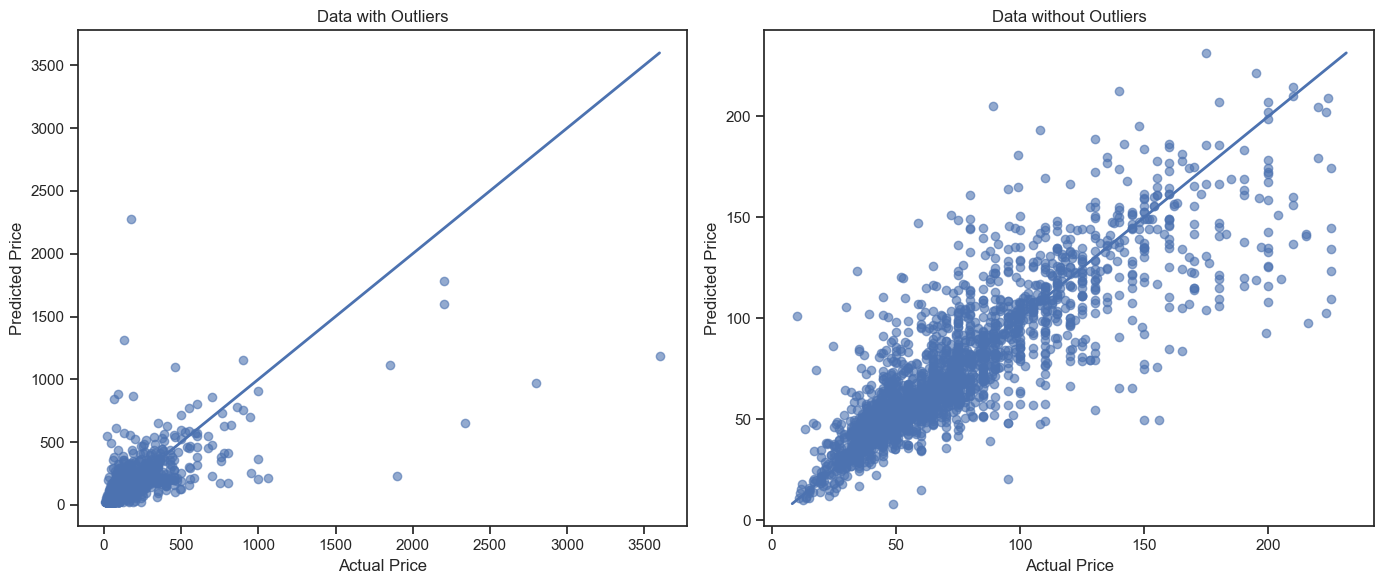

In [80]:
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)

plt.scatter(Resp_test, Y_pred, alpha=0.6)

minimum = min(Resp_test.min(), Y_pred.min())
maximum = max(Resp_test.max(), Y_pred.max())

plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    linewidth=2
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Data with Outliers")


plt.subplot(1, 2, 2)

plt.scatter(Resp_test2, Y_pred2, alpha=0.6)

minimum = min(Resp_test2.min(), Y_pred2.min())
maximum = max(Resp_test2.max(), Y_pred2.max())

plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    linewidth=2
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Data without Outliers")

plt.tight_layout()
plt.show()

The model improved After removing the outliers from 47% to 71%
